# <b><font color='skyblue'>Статистика. Revision</font></b>

In [27]:
# Импорт библиотек
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

### <b><font color='skyblue'>1. Описательная статистика</font></b>

##### <b><font color='skyblue'>1.1. Меры центральной тенденции</font></b>
Это статистические показатели, которые описывают центральную точку или типичное значение набора данных.

In [6]:
# Используя файл shopping_behavior_updated.csv вычислите меры центральной тенденции для суммы покупки
shopping = pd.read_csv('..//data//shopping_behavior_updated.csv')
shopping.head()


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [11]:
print('Среднее значение покупки:', shopping['Purchase Amount (USD)'].mean())  # среднее
print('Медиана покупки:', shopping['Purchase Amount (USD)'].median())  # медиана
print('Мода покупки:', shopping['Purchase Amount (USD)'].mode().values[0])  # мода


Среднее значение покупки: 59.76435897435898
Медиана покупки: 60.0
Мода покупки: 32


In [12]:
print('Среднее значение предыдущих покупок:', shopping['Previous Purchases'].mean())  # среднее
print('Медиана предыдущих покупок:', shopping['Previous Purchases'].median())  # медиана
print('Мода предыдущих покупок:', shopping['Previous Purchases'].mode().values[0])  # мода

Среднее значение предыдущих покупок: 25.35153846153846
Медиана предыдущих покупок: 25.0
Мода предыдущих покупок: 31


##### <b><font color='skyblue'>1.2. Меры дисперсии</font></b>

In [16]:
# Для суммы покупки предыдущего датасета вычислите меры дисперсии
print('Дисперсия суммы покупки:', shopping['Purchase Amount (USD)'].var())  # дисперсия
print('Стандартное отклонение суммы покупки:', shopping['Purchase Amount (USD)'].std())  # стандартное отклонение
print('Минимальная сумма покупки:', shopping['Purchase Amount (USD)'].min())  # минимум
print('Средняя суммы покупки:', shopping['Purchase Amount (USD)'].mean())  # средняя абсолютная девиация
print('Максимальная сумма покупки:', shopping['Purchase Amount (USD)'].max())  # максимум
print('25-й перцентиль суммы покупки:', shopping['Purchase Amount (USD)'].quantile(0.25))  # 25-й перцентиль
print('75-й перцентиль суммы покупки:', shopping['Purchase Amount (USD)'].quantile(0.75)) # 75-й перцентиль
IQR = shopping['Purchase Amount (USD)'].quantile(0.75) - shopping['Purchase Amount (USD)'].quantile(0.25)  # межквартильный размах
print('Межквартильный размах суммы покупки:', IQR)  # межквартильный размах

Дисперсия суммы покупки: 560.997806077824
Стандартное отклонение суммы покупки: 23.685392250875307
Минимальная сумма покупки: 20
Средняя суммы покупки: 59.76435897435898
Максимальная сумма покупки: 100
25-й перцентиль суммы покупки: 39.0
75-й перцентиль суммы покупки: 81.0
Межквартильный размах суммы покупки: 42.0


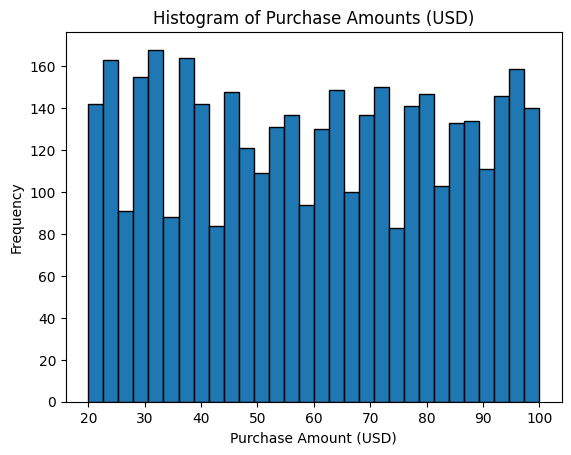

In [30]:
shopping['Purchase Amount (USD)'].plot(kind='hist', bins=30, edgecolor='black')
plt.xlabel('Purchase Amount (USD)')
plt.ylabel('Frequency')
plt.title('Histogram of Purchase Amounts (USD)')
plt.show()


### <u><b><font color='skyblue'>2. Проверка гипотез</font></b></u>

##### <b><font color='skyblue'>Есть ли различия в среднем уровне трат между мужчинами и женщинами?</font></b>

In [31]:
# Есть ли различия в среднем уровне трат между мужчинами и женщинами
a = shopping.groupby('Gender')['Purchase Amount (USD)'].mean()
print(a)
b = shopping.groupby('Gender')['Purchase Amount (USD)'].std()
print(b)
male = shopping[shopping['Gender'] == 'Male']['Purchase Amount (USD)']
female = shopping[shopping['Gender'] == 'Female']['Purchase Amount (USD)']
t_stat, p_value = stats.ttest_ind(male, female, equal_var=False)
print(f'T-statistic: {t_stat}, P-value: {p_value}')
if p_value < 0.05:
    print("Существует статистически значимая разница в среднем уровне трат между мужчинами и женщинами.")
else:
    print("Нет статистически значимой разницы в среднем уровне трат между мужчинами и женщинами.")
    


Gender
Female    60.249199
Male      59.536199
Name: Purchase Amount (USD), dtype: float64
Gender
Female    23.420556
Male      23.809976
Name: Purchase Amount (USD), dtype: float64
T-statistic: -0.8821375008076587, P-value: 0.3777879760611915
Нет статистически значимой разницы в среднем уровне трат между мужчинами и женщинами.


##### <b><font color='skyblue'>Менеджер утверждает, что средний возраст покупателей - 35 лет. Проверьте это утверждение.</font></b>

In [21]:
# Менеджер утверждает, что средний возраст покупателей - 35 лет. Проверьте это утверждение.
# 1. Вычислите среднее значение и стандартную ошибку
mean_age = shopping['Age'].mean()
sem_age = shopping['Age'].sem()
# 2. Определите ДИ
confidence = 0.95
# 3. Вычислите ДИ
ci = stats.t.interval(confidence = confidence,
                   df = len(shopping) - 1, 
                   loc = mean_age, 
                   scale = sem_age)
# для больших выборок или с известным 𝜎:
# stats.norm.interval(confidence = confidence, loc = mean_age, scale = sem_age)
print(f'95% ДИ для среднего возраста покупателей: {ci}')

# Проверка утверждения менеджера
manager_claim = 35
if ci[0] <= manager_claim <= ci[1]:
    print(f"Утверждение менеджера о среднем возрасте {manager_claim} лет подтверждается.")
else:
    print(f"Утверждение менеджера о среднем возрасте {manager_claim} лет не подтверждается.")



95% ДИ для среднего возраста покупателей: (np.float64(43.59103011932336), np.float64(44.545892957599726))
Утверждение менеджера о среднем возрасте 35 лет не подтверждается.


##### <b><font color='skyblue'>Существует ли зависимость между полом клиента и цветом выбираемой одежды?</font></b>

In [23]:
# Существует ли зависимость между полом клиента и цветом выбираемой одежды
contingency_table = pd.crosstab(shopping['Gender'], shopping['Color'])
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
print(f'Chi2: {chi2}, p-value: {p}')
if p < 0.05:
    print("Существует статистически значимая зависимость между полом клиента и цветом выбираемой одежды.")
else:
    print("Нет статистически значимой зависимости между полом клиента и цветом выбираемой одежды.")
    

Chi2: 12.638531574208868, p-value: 0.9717119112341447
Нет статистически значимой зависимости между полом клиента и цветом выбираемой одежды.


### <b><font color='skyblue'>3. Доверительный интервал</font></b>

##### <b><font color='skyblue'>3.1. Рассчитайте доверительный интервал для возраста покупателей магазина</font></b>

In [17]:
# 1. Вычислите среднее значение и стандартную ошибку
mean_age = shopping['Age'].mean()
sem_age = shopping['Age'].sem()
# 2. Определите ДИ
confidence = 0.95
# 3. Вычислите ДИ
ci = stats.t.interval(confidence = confidence, 
                   df = len(shopping) - 1, 
                   loc = mean_age, 
                   scale = sem_age)
# для больших выборок или с известным 𝜎:
# st.norm.interval(confidence = confidence, df = len(data)-1, loc = mean, scale = sem)
ci

(np.float64(43.59103011932336), np.float64(44.545892957599726))

##### <b><font color='skyblue'>Вычислите ДИ для доли мужчин среди всех покупателей магазина</font></b>

In [18]:
from statsmodels.stats.proportion import proportion_confint

# Данные
n = len(shopping)
x = shopping[shopping['Gender'] == 'Male'].count()[0]
confidence = 0.95
alpha = 1 - confidence

# Расчёт доверительного интервала
lower, upper = proportion_confint(count = x, nobs = n, alpha = alpha, method = 'normal')

print(f"95%-ный доверительный интервал для доли: ({lower:.3f}, {upper:.3f})")

95%-ный доверительный интервал для доли: (0.665, 0.695)


C:\Users\Vitaliy\AppData\Local\Temp\ipykernel_24652\83991446.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x = shopping[shopping['Gender'] == 'Male'].count()[0]


In [19]:
shopping[shopping['Gender'] == 'Male'].count()[0]

C:\Users\Vitaliy\AppData\Local\Temp\ipykernel_24652\3709759463.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  shopping[shopping['Gender'] == 'Male'].count()[0]


np.int64(2652)